# Benchmark: Pauli Propagation vs Other Executors

This notebook compares execution speed of `PauliPropagationExecutor` against `PennylaneExecutor`, `QulacsExecutor`, and `QiskitExecutor` for computing expectation values of quantum circuits.

Pauli propagation works in the Heisenberg picture and is most efficient when the observable is sparse (few Pauli terms) and the circuit doesn't generate too many new terms during propagation.

In [1]:
import numpy as np
import time
from executor import QuantumCircuit, QuantumOperator

# Import all available executors
executors = {}

from executor.pauli_propagation import PauliPropagationExecutor
executors['PauliPropagation'] = PauliPropagationExecutor(seed=0)

try:
    from executor.pennylane.pennylane_executor import PennylaneExecutor
    executors['PennyLane'] = PennylaneExecutor(seed=0)
except ImportError as e:
    print(f'PennyLane not available: {e}')

try:
    from executor.qulacs.qulacs_executor import QulacsExecutor
    executors['Qulacs'] = QulacsExecutor(seed=0)
except ImportError as e:
    print(f'Qulacs not available: {e}')

try:
    from executor.qiskit.qiskit_executor import QiskitExecutor
    executors['Qiskit'] = QiskitExecutor(seed=0)
except ImportError as e:
    print(f'Qiskit executor not available: {e}')

print(f'Available executors: {list(executors.keys())}')

Qiskit executor not available: cannot import name 'ProviderV1' from 'qiskit.providers' (c:\Users\mcr\AppData\Local\Programs\Python\Python312\Lib\site-packages\qiskit\providers\__init__.py)
Available executors: ['PauliPropagation', 'PennyLane', 'Qulacs']


## Helper functions

In [2]:
def build_clifford_circuit(n_qubits, depth=10):
    """Build a deep Clifford circuit with a single rotation at the end.
    
    This is favorable for Pauli propagation: Clifford gates map Pauli
    strings to Pauli strings (no term splitting), so the observable
    stays compact throughout propagation.
    """
    qc = QuantumCircuit(n_qubits)
    for _ in range(depth):
        for q in range(n_qubits):
            qc.h(q)
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
    # Only 1 rotation gate at the end
    qc.rz(0, 0.1)
    return qc


def build_rotation_circuit(n_qubits, depth=5):
    """Build a circuit with many rotation gates.
    
    This is harder for Pauli propagation: each non-commuting rotation
    can double the number of Pauli terms in the observable.
    """
    qc = QuantumCircuit(n_qubits)
    for _ in range(depth):
        for q in range(n_qubits):
            qc.rx(q, 0.3 * (q + 1))
            qc.rz(q, 0.2 * (q + 1))
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
    return qc


def time_executor(executor, circuit, operator, n_runs=5):
    """Time an executor's expectation_value call. Returns (mean_time, result)."""
    # Warmup
    try:
        result = executor.expectation_value(circuit, operator)
    except Exception as e:
        return None, str(e)
    
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        result = executor.expectation_value(circuit, operator)
        elapsed = time.perf_counter() - start
        times.append(elapsed)
    
    return np.mean(times), result


def run_benchmark(circuit, operator, label, n_runs=5):
    """Run all executors on a given circuit+operator and print results."""
    print(f'\n{"=" * 60}')
    print(f'{label}')
    print(f'{"=" * 60}')
    
    results = {}
    for name, executor in executors.items():
        t, val = time_executor(executor, circuit, operator, n_runs=n_runs)
        if t is not None:
            results[name] = (t, val)
            print(f'  {name:20s}  {t*1000:8.2f} ms   result = {val:.10f}')
        else:
            print(f'  {name:20s}  FAILED: {val}')
    
    # Show speedup relative to fastest statevector method
    sv_times = {k: v[0] for k, v in results.items() if k != 'PauliPropagation'}
    if sv_times and 'PauliPropagation' in results:
        pp_time = results['PauliPropagation'][0]
        fastest_sv = min(sv_times.values())
        fastest_name = min(sv_times, key=sv_times.get)
        speedup = fastest_sv / pp_time
        if speedup > 1:
            print(f'  -> PauliPropagation is {speedup:.1f}x faster than {fastest_name}')
        else:
            print(f'  -> PauliPropagation is {1/speedup:.1f}x slower than {fastest_name}')
    
    return results

## Benchmark 1: Clifford circuit + sparse observable

This is the best-case scenario for Pauli propagation. The circuit is mostly Clifford gates (H, CNOT) which don't increase the number of Pauli terms, and the observable has only 1 term.

In [3]:
for n_qubits in [4, 8, 12, 16, 20]:
    circuit = build_clifford_circuit(n_qubits, depth=10)
    n_gates = len(circuit._qiskit_circuit.data)
    
    # Single Pauli term observable
    obs_str = 'Z' + 'I' * (n_qubits - 1)
    operator = QuantumOperator([obs_str], [1.0])
    
    run_benchmark(
        circuit, operator,
        f'Clifford circuit: {n_qubits} qubits, {n_gates} gates, 1 Pauli term',
        n_runs=3
    )


Clifford circuit: 4 qubits, 71 gates, 1 Pauli term
  PauliPropagation          1.97 ms   result = 1.0000000000
  PennyLane                11.27 ms   result = 1.0000000000
  Qulacs                FAILED: tuple index out of range
  -> PauliPropagation is 5.7x faster than PennyLane

Clifford circuit: 8 qubits, 151 gates, 1 Pauli term
  PauliPropagation          1.03 ms   result = 1.0000000000
  PennyLane                22.20 ms   result = 1.0000000000
  Qulacs                FAILED: tuple index out of range
  -> PauliPropagation is 21.6x faster than PennyLane

Clifford circuit: 12 qubits, 231 gates, 1 Pauli term
  PauliPropagation          1.98 ms   result = 1.0000000000
  PennyLane                61.24 ms   result = 1.0000000000
  Qulacs                FAILED: tuple index out of range
  -> PauliPropagation is 31.0x faster than PennyLane

Clifford circuit: 16 qubits, 311 gates, 1 Pauli term
  PauliPropagation          3.04 ms   result = 1.0000000000
  PennyLane               622.57 ms   

## Benchmark 2: Clifford circuit + multi-term observable

Same Clifford-heavy circuit but with a 3-term observable. Pauli propagation handles each term independently.

In [4]:
for n_qubits in [4, 8, 12, 16, 20]:
    circuit = build_clifford_circuit(n_qubits, depth=10)
    n_gates = len(circuit._qiskit_circuit.data)
    
    # 3-term observable
    paulis = [
        'Z' + 'I' * (n_qubits - 1),
        'I' * (n_qubits - 1) + 'Z',
        'ZZ' + 'I' * (n_qubits - 2),
    ]
    operator = QuantumOperator(paulis, [0.5, 0.3, 0.2])
    
    run_benchmark(
        circuit, operator,
        f'Clifford circuit: {n_qubits} qubits, {n_gates} gates, 3 Pauli terms',
        n_runs=3
    )


Clifford circuit: 4 qubits, 71 gates, 3 Pauli terms
  PauliPropagation          1.77 ms   result = 1.0000000000
  PennyLane                28.76 ms   result = 3.0000000000
  Qulacs                FAILED: tuple index out of range
  -> PauliPropagation is 16.2x faster than PennyLane

Clifford circuit: 8 qubits, 151 gates, 3 Pauli terms
  PauliPropagation          4.05 ms   result = 1.0000000000
  PennyLane                27.40 ms   result = 3.0000000000
  Qulacs                FAILED: tuple index out of range
  -> PauliPropagation is 6.8x faster than PennyLane

Clifford circuit: 12 qubits, 231 gates, 3 Pauli terms
  PauliPropagation          3.61 ms   result = 1.0000000000
  PennyLane                40.75 ms   result = 3.0000000000
  Qulacs                FAILED: tuple index out of range
  -> PauliPropagation is 11.3x faster than PennyLane

Clifford circuit: 16 qubits, 311 gates, 3 Pauli terms
  PauliPropagation          4.05 ms   result = 1.0000000000
  PennyLane               542.52 m

## Benchmark 3: Rotation-heavy circuit (depth=1)

Circuits with many parametric rotations cause Pauli propagation to generate exponentially many terms. This tests where Pauli propagation loses its advantage.

**Note:** Using depth=1 here because the Pauli propagation module currently has a known accuracy issue with deeper rotation-heavy circuits (depth >= 2). Clifford-dominated circuits (Benchmarks 1, 2, 5) work correctly at any depth.

In [5]:
for n_qubits in [4, 6, 8, 10, 12]:
    circuit = build_rotation_circuit(n_qubits, depth=1)
    n_gates = len(circuit._qiskit_circuit.data)
    
    obs_str = 'Z' + 'I' * (n_qubits - 1)
    operator = QuantumOperator([obs_str], [1.0])
    
    run_benchmark(
        circuit, operator,
        f'Rotation circuit: {n_qubits} qubits, {n_gates} gates, depth=1',
        n_runs=3
    )


Rotation circuit: 4 qubits, 11 gates, depth=1
  PauliPropagation          0.61 ms   result = 0.1775998040
  PennyLane                 2.74 ms   result = 0.1775998040
  Qulacs                FAILED: tuple index out of range
  -> PauliPropagation is 4.5x faster than PennyLane

Rotation circuit: 6 qubits, 17 gates, depth=1
  PauliPropagation          1.03 ms   result = -0.0028543202
  PennyLane                 3.24 ms   result = -0.0028543202
  Qulacs                FAILED: tuple index out of range
  -> PauliPropagation is 3.1x faster than PennyLane

Rotation circuit: 8 qubits, 23 gates, depth=1
  PauliPropagation          4.48 ms   result = -0.0010625788
  PennyLane                 4.04 ms   result = -0.0010625788
  Qulacs                FAILED: tuple index out of range
  -> PauliPropagation is 1.1x slower than PennyLane

Rotation circuit: 10 qubits, 29 gates, depth=1
  PauliPropagation         22.58 ms   result = -0.0009510342
  PennyLane                 5.54 ms   result = -0.000951034

## Benchmark 4: Pauli propagation with truncation

Truncation keeps only significant Pauli terms, trading exact accuracy for speed. This makes rotation-heavy circuits tractable at the cost of a small approximation error.

In [6]:
n_qubits = 12
circuit = build_rotation_circuit(n_qubits, depth=1)
n_gates = len(circuit._qiskit_circuit.data)
obs_str = 'Z' + 'I' * (n_qubits - 1)
operator = QuantumOperator([obs_str], [1.0])

print(f'Circuit: {n_qubits} qubits, {n_gates} gates, depth=1')
print()

# Exact (no truncation)
exec_exact = PauliPropagationExecutor()
t_exact, val_exact = time_executor(exec_exact, circuit, operator, n_runs=3)
if t_exact is not None:
    print(f'  Exact:                {t_exact*1000:8.2f} ms   result = {val_exact:.10f}')
else:
    print(f'  Exact:                FAILED (too many terms)')
    val_exact = None

# With various truncation thresholds
for threshold in [1e-2, 1e-4, 1e-6, 1e-8]:
    exec_trunc = PauliPropagationExecutor(truncate_threshold=threshold)
    t, val = time_executor(exec_trunc, circuit, operator, n_runs=3)
    if t is not None:
        error = abs(val - val_exact) if val_exact is not None else float('nan')
        stats = exec_trunc.get_truncation_stats()
        n_remaining = stats.terms_remaining if stats else '?'
        print(f'  threshold={threshold:.0e}:  {t*1000:8.2f} ms   result = {val:.10f}   error = {error:.2e}   terms = {n_remaining}')
    else:
        print(f'  threshold={threshold:.0e}:  FAILED')

Circuit: 12 qubits, 35 gates, depth=1

  Exact:                  121.72 ms   result = -0.0008421700
  threshold=1e-02:    102.60 ms   result = 0.0000000000   error = 8.42e-04   terms = 389
  threshold=1e-04:     96.82 ms   result = -0.0008421700   error = 0.00e+00   terms = 3074
  threshold=1e-06:    101.12 ms   result = -0.0008421700   error = 0.00e+00   terms = 4094
  threshold=1e-08:    121.67 ms   result = -0.0008421700   error = 0.00e+00   terms = 4096


## Benchmark 5: Scaling with qubit count (Clifford circuit)

Statevector-based methods scale as O(2^n). Pauli propagation with sparse observables on Clifford circuits stays polynomial.

In [7]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)  # suppress large-qubit warnings

qubit_counts = [4, 8, 12, 16, 20, 24]
timing_data = {name: [] for name in executors}

for n_qubits in qubit_counts:
    circuit = build_clifford_circuit(n_qubits, depth=10)
    obs_str = 'Z' + 'I' * (n_qubits - 1)
    operator = QuantumOperator([obs_str], [1.0])
    
    print(f'\n{n_qubits} qubits:')
    for name, executor in executors.items():
        # Skip statevector methods for large qubit counts
        if name != 'PauliPropagation' and n_qubits > 20:
            timing_data[name].append(None)
            print(f'  {name:20s}  skipped (too large for statevector)')
            continue
        
        t, val = time_executor(executor, circuit, operator, n_runs=3)
        timing_data[name].append(t)
        if t is not None:
            print(f'  {name:20s}  {t*1000:8.2f} ms')
        else:
            print(f'  {name:20s}  FAILED')


4 qubits:
  PauliPropagation          0.62 ms
  PennyLane                 8.09 ms
  Qulacs                FAILED

8 qubits:
  PauliPropagation          1.01 ms
  PennyLane                19.23 ms
  Qulacs                FAILED

12 qubits:
  PauliPropagation          1.39 ms
  PennyLane                43.99 ms
  Qulacs                FAILED

16 qubits:
  PauliPropagation          2.20 ms
  PennyLane               429.09 ms
  Qulacs                FAILED

20 qubits:
  PauliPropagation          2.66 ms
  PennyLane              8165.01 ms
  Qulacs                FAILED

24 qubits:
  PauliPropagation          2.84 ms
  PennyLane             skipped (too large for statevector)
  Qulacs                skipped (too large for statevector)


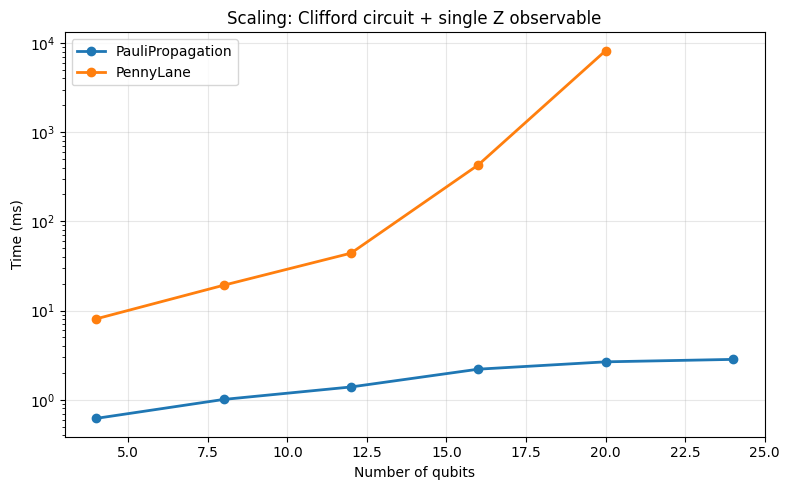

In [8]:
# Plot scaling
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, times in timing_data.items():
        valid = [(q, t) for q, t in zip(qubit_counts, times) if t is not None]
        if valid:
            qs, ts = zip(*valid)
            ax.plot(qs, [t * 1000 for t in ts], 'o-', label=name, linewidth=2)
    
    ax.set_xlabel('Number of qubits')
    ax.set_ylabel('Time (ms)')
    ax.set_title('Scaling: Clifford circuit + single Z observable')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not installed, skipping plot')

## Summary

| Scenario | Pauli Propagation | Statevector methods |
|---|---|---|
| Clifford circuit + sparse observable | Very fast (polynomial) | O(2^n) |
| Clifford circuit + dense observable | Fast (linear in # terms) | O(2^n) |
| Rotation-heavy circuit | Exponential term growth | O(2^n) |
| Rotation-heavy + truncation | Controllable tradeoff | O(2^n) |